# Mae Sai real-data and ML orientation

## Goal and current decision

This notebook answers three questions with the current governed real data:

1. What is actually present in the aligned Sentinel-1 feature pool?
2. Which backscatter-change and static-context patterns are present?
3. Is an honest supervised logistic-versus-HGB experiment authorized yet?

**Answer:** the real measurements are structurally ready for aggregate analysis.
An unsupervised pattern-learning exercise is possible now. A supervised flood
classifier is not: there are no released real labels or release-bound training
table. The expected training-gate result is
`blocked_missing_released_training_labels`.

Exposure lane: `reviewer_a_safe`. This notebook deliberately hides query IDs,
locations, weak-overlap rows, model scores, priorities, queues, and answer
geometry. Nothing here is a flood map, formal review, model evaluation, FPPS
input, or warning.


## Setup

The notebook reads a previously verified aggregate orientation artifact and the
four full-scene processed rasters. Paths are supplied through environment
variables by the builder; no personal filesystem path is embedded here.

The heavy 628 MB cell-level validation and aggregation lives in the reusable,
tested `real_data_orientation` module. This notebook verifies that artifact,
then teaches from its bounded outputs.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import sys

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

repository_root = Path.cwd()
sys.path.insert(0, str(repository_root / "src"))

from floodguard.label_factory.real_data_orientation import (
    verify_real_data_orientation_artifact,
)

orientation_dir = Path(os.environ["FLOODGUARD_ORIENTATION_DIR"])
pilot_root = Path(os.environ["FLOODGUARD_MAE_SAI_PILOT_ROOT"])
executed_at_utc = os.environ["FLOODGUARD_NOTEBOOK_EXECUTED_AT_UTC"]

verify_real_data_orientation_artifact(orientation_dir)
summary = json.loads((orientation_dir / "summary.json").read_text(encoding="utf-8"))
feature_quantiles = pd.read_csv(orientation_dir / "feature_quantiles.csv")
change_histograms = pd.read_csv(orientation_dir / "change_histograms.csv")
context_summary = pd.read_csv(orientation_dir / "context_summary.csv")
pca_summary = pd.read_csv(orientation_dir / "pca_summary.csv")
cluster_sensitivity = pd.read_csv(orientation_dir / "cluster_sensitivity.csv")
cluster_summary = pd.read_csv(orientation_dir / "cluster_summary.csv")

forbidden_fragments = (
    "query_region_id",
    "tile_id",
    "bbox",
    "longitude",
    "latitude",
    "weak_label",
    "weak_positive",
    "model_score",
    "priority",
    "selection_rank",
    "label_code",
)
for table_name, table in {
    "feature_quantiles": feature_quantiles,
    "change_histograms": change_histograms,
    "context_summary": context_summary,
    "pca_summary": pca_summary,
    "cluster_sensitivity": cluster_sensitivity,
    "cluster_summary": cluster_summary,
}.items():
    lowered = {column.lower() for column in table.columns}
    leaked = sorted(
        column
        for column in lowered
        if any(fragment in column for fragment in forbidden_fragments)
    )
    assert not leaked, f"Reviewer-safe table {table_name} leaked fields: {leaked}"

assert summary["exposure_lane"] == "reviewer_a_safe"
assert summary["training_gate_status"] == "blocked_missing_released_training_labels"
safety = summary["safety"]
counts = summary["counts"]
assert safety["report_only"] is True
assert safety["formal_review_authorized"] is False
assert safety["eligible_for_query_model_training"] is False
assert safety["eligible_for_decision_layer"] is False
assert safety["eligible_for_fpps"] is False
assert safety["eligible_for_warning"] is False
assert safety["contains_released_training_labels"] is False

print("Artifact verification: passed")
print(f"Notebook execution timestamp: {executed_at_utc}")


Artifact verification: passed
Notebook execution timestamp: 2026-07-13T03:29:30Z


## Checks: governed inputs and data grain

One row in the source pool is one 10 m-grid cell inside one 32 × 32 query core.
Those cells are not independent observations: neighboring cells share the same
scene, weather, processing, terrain, and query context. The future validation
unit is therefore a spatial group, not a randomly selected cell.

The feature contract contains four backscatter measurements, two exact change
features, and one support field:

`pre_vv_db`, `event_vv_db`, `pre_vh_db`, `event_vh_db`, `vv_change_db`,
`vh_change_db`, and `valid_data_fraction`.

FloodGuard uses `change = pre - event`: positive change means event-time
backscatter became darker; negative change means it became brighter. Neither
direction is a flood label.


In [2]:
data_profile = pd.DataFrame(
    [
        ("Cell rows", counts["cell_count"]),
        ("Query cores", counts["query_count"]),
        ("Cells per query", counts["cells_per_query"]),
        ("Spatial groups", counts["spatial_group_count"]),
        ("Released real labels", 0),
    ],
    columns=["measure", "observed"],
)
data_profile


,measure,observed
0,Cell rows,874496
1,Query cores,854
2,Cells per query,1024
3,Spatial groups,20
4,Released real labels,0


In [3]:
quantile_view = feature_quantiles.pivot(
    index="feature", columns="statistic", values="value"
).reset_index()
quantile_view


statistic,feature,maximum,mean,median,minimum,p05,p25,p75,p95,standard_deviation
0,event_vh_db,10.564125,-13.901653,-13.783751,-51.394348,-18.607383,-15.569597,-12.085547,-9.594431,2.866917
1,event_vv_db,25.033398,-6.513030,-6.617665,-34.706615,-11.203847,-8.437979,-4.758010,-1.620284,3.116711
2,pre_vh_db,10.319743,-13.875773,-13.775407,-51.520302,-18.445446,-15.532546,-12.106496,-9.644498,2.789862
3,pre_vv_db,25.533276,-6.717958,-6.819899,-32.496353,-11.319472,-8.611756,-4.992232,-1.934972,3.047376
4,valid_data_fraction,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
5,vh_change_db,37.086917,0.025880,0.011166,-31.322865,-4.684673,-1.855453,1.891441,4.777253,2.928065
6,vv_change_db,24.608333,-0.204928,-0.205400,-21.802510,-4.531210,-1.926844,1.520616,4.115498,2.640628


## Step 1: inspect real SAR-change distributions

The following curves describe measured backscatter change—not flood
probability. The vertical zero line separates event-time darkening (positive
`pre - event`) from event-time brightening (negative `pre - event`). Both tails
can contain flood-compatible and non-flood explanations.


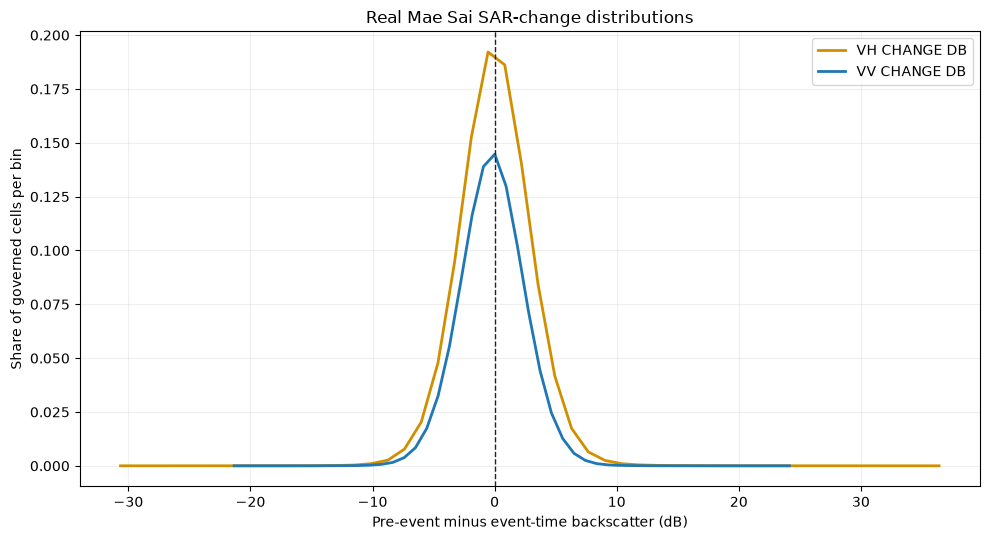

In [4]:
histogram_plot = change_histograms.copy()
histogram_plot["bin_center"] = (
    histogram_plot["bin_left"] + histogram_plot["bin_right"]
) / 2

fig, ax = plt.subplots(figsize=(10, 5.5))
palette = {"vv_change_db": "#1f77b4", "vh_change_db": "#d18f00"}
for feature_name, rows in histogram_plot.groupby("feature", sort=True):
    rows = rows.sort_values("bin_index")
    share = rows["cell_count"] / rows["cell_count"].sum()
    ax.plot(
        rows["bin_center"],
        share,
        label=feature_name.replace("_", " ").upper(),
        color=palette.get(feature_name, "#555555"),
        linewidth=2,
    )
ax.axvline(0, color="#222222", linestyle="--", linewidth=1)
ax.set_title("Real Mae Sai SAR-change distributions")
ax.set_xlabel("Pre-event minus event-time backscatter (dB)")
ax.set_ylabel("Share of governed cells per bin")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


## Step 2: view the full real scene without labels

The same fixed stretch is used within each polarization so the pre/event images
are visually comparable. Change panels use a symmetric scale around zero.
There are no query boxes, weak polygons, predictions, scores, or priorities.

Look for coherent darkening and brightening, then immediately name competing
explanations: open water, urban double-bounce, flooded vegetation, wet soil,
agricultural change, terrain effects, speckle, or registration boundaries.


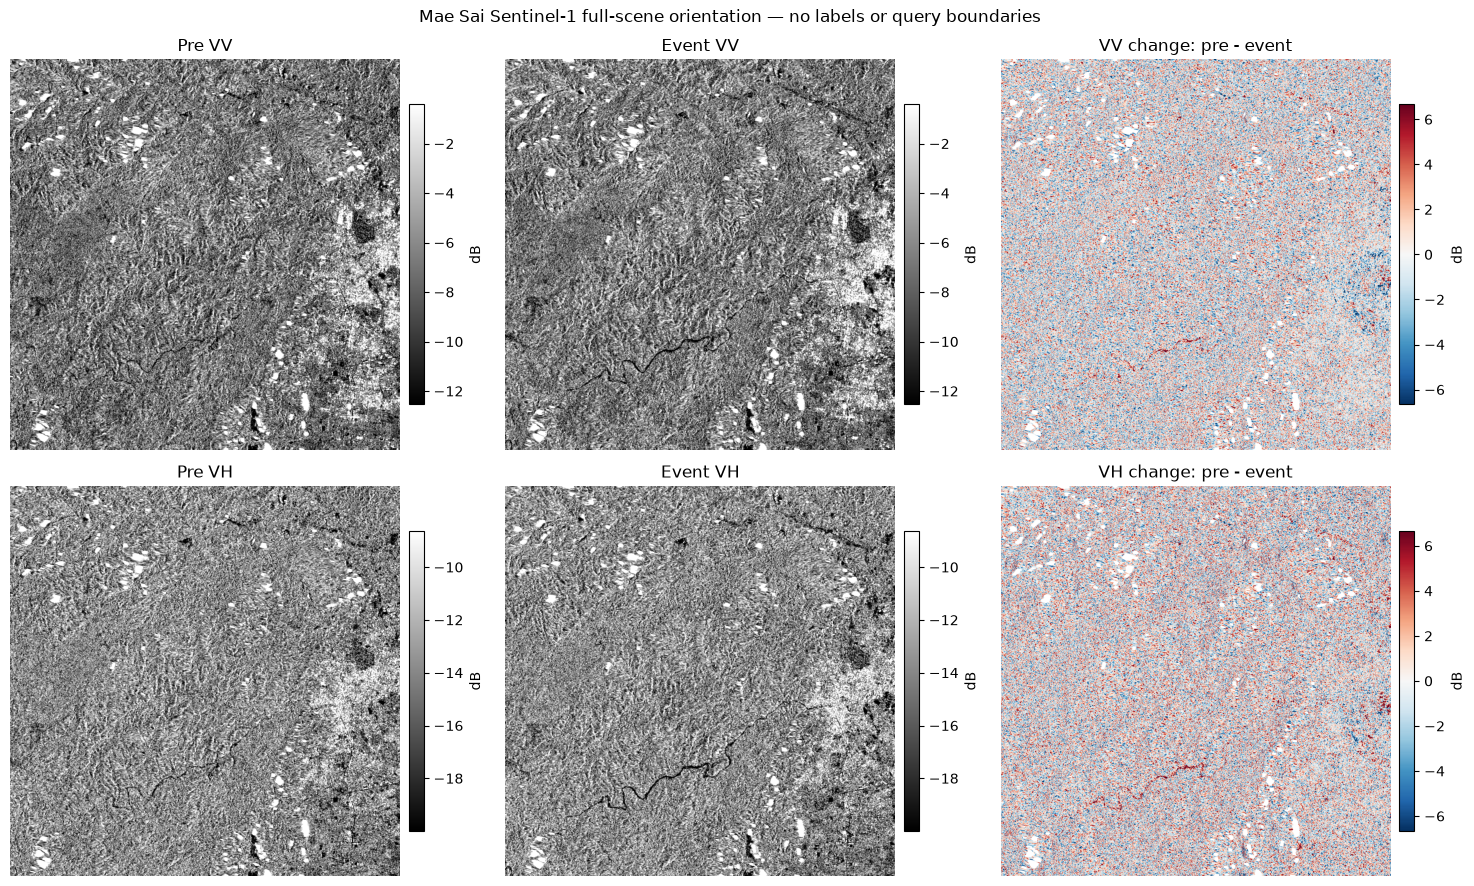

In [5]:
raster_paths = {
    "Pre VV": pilot_root / "processing/pre_20240903_rtc_v1/pre_20240903_vv_db.tif",
    "Event VV": pilot_root / "processing/event_20240915_rtc_v1/event_20240915_vv_db.tif",
    "Pre VH": pilot_root / "processing/pre_20240903_rtc_v1/pre_20240903_vh_db.tif",
    "Event VH": pilot_root / "processing/event_20240915_rtc_v1/event_20240915_vh_db.tif",
}

def read_valid_raster(path: Path) -> np.ndarray:
    with rasterio.open(path) as source:
        array = source.read(1, masked=True).filled(np.nan).astype("float32")
    return array

rasters = {name: read_valid_raster(path) for name, path in raster_paths.items()}
vv_change = rasters["Pre VV"] - rasters["Event VV"]
vh_change = rasters["Pre VH"] - rasters["Event VH"]

vv_low, vv_high = np.nanpercentile(
    np.concatenate([rasters["Pre VV"].ravel(), rasters["Event VV"].ravel()]),
    [2, 98],
)
vh_low, vh_high = np.nanpercentile(
    np.concatenate([rasters["Pre VH"].ravel(), rasters["Event VH"].ravel()]),
    [2, 98],
)
change_limit = float(
    np.nanpercentile(np.abs(np.concatenate([vv_change.ravel(), vh_change.ravel()])), 98)
)

panels = [
    ("Pre VV", rasters["Pre VV"], "gray", vv_low, vv_high),
    ("Event VV", rasters["Event VV"], "gray", vv_low, vv_high),
    ("VV change: pre - event", vv_change, "RdBu_r", -change_limit, change_limit),
    ("Pre VH", rasters["Pre VH"], "gray", vh_low, vh_high),
    ("Event VH", rasters["Event VH"], "gray", vh_low, vh_high),
    ("VH change: pre - event", vh_change, "RdBu_r", -change_limit, change_limit),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, (title, image, cmap, minimum, maximum) in zip(axes.ravel(), panels, strict=True):
    rendered = axis.imshow(image, cmap=cmap, vmin=minimum, vmax=maximum)
    axis.set_title(title)
    axis.set_axis_off()
    fig.colorbar(rendered, ax=axis, fraction=0.035, pad=0.02, label="dB")
fig.suptitle("Mae Sai Sentinel-1 full-scene orientation — no labels or query boundaries")
plt.tight_layout()
plt.show()


## Step 3: understand static-context imbalance

Context strata help diagnose where SAR interpretation may fail; they are not
event-time labels. Small slices cannot support reliable performance claims.
The current pool is dominated by steep-terrain context, while water-edge and
cropland strata are sparse.


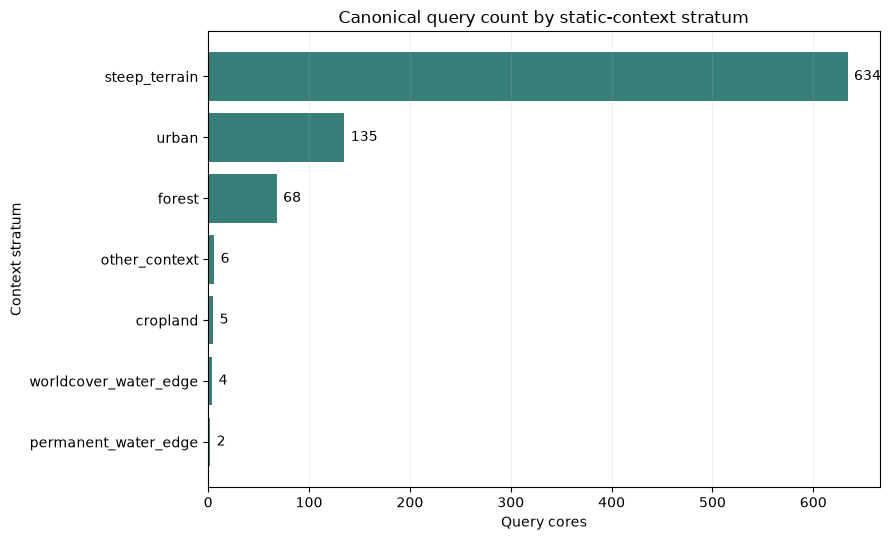

,context_stratum,query_count,spatial_group_count,mean_permanent_water_fraction,mean_worldcover_water_fraction,mean_urban_fraction,mean_forest_fraction,mean_cropland_fraction,mean_steep_terrain_fraction,mean_slope_p90_degrees,descriptive_only_small_slice
0,cropland,5,2,0.000000,0.000000,0.148438,0.098828,0.510547,0.001367,5.537668,True
1,forest,68,13,0.000000,0.004696,0.049977,0.622415,0.118695,0.081916,12.316690,False
2,other_context,6,5,0.000000,0.000000,0.044596,0.165202,0.052897,0.042480,11.373693,True
3,permanent_water_edge,2,1,0.012207,0.058594,0.060547,0.514648,0.152832,0.080078,14.495287,True
4,steep_terrain,634,19,0.000000,0.000071,0.004733,0.861960,0.013680,0.718668,28.293426,False
5,urban,135,7,0.000000,0.000246,0.671137,0.216688,0.059361,0.037435,7.707116,False
6,worldcover_water_edge,4,3,0.000000,0.050049,0.039795,0.125977,0.059082,0.049072,11.763784,True


In [6]:
context_plot = context_summary.sort_values("query_count", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(context_plot["context_stratum"], context_plot["query_count"], color="#397f79")
ax.set_title("Canonical query count by static-context stratum")
ax.set_xlabel("Query cores")
ax.set_ylabel("Context stratum")
ax.grid(axis="x", alpha=0.2)
for bar, value in zip(bars, context_plot["query_count"], strict=True):
    ax.text(value + max(context_plot["query_count"]) * 0.01, bar.get_y() + bar.get_height()/2, str(int(value)), va="center")
plt.tight_layout()
plt.show()

context_summary


## Step 4: learn ML without inventing flood labels

PCA and k-means are unsupervised methods: they organize feature variation
without a flood target.

- **PCA** rotates correlated query-level summaries into a smaller set of axes.
- **K-means** groups queries with similar standardized summaries.
- **Silhouette score** measures separation and compactness of those groups.

Cluster IDs are arbitrary pattern groups. They are not dry, flood, permanent
water, uncertainty, artifact, probability, accuracy, or reviewer priority.


In [7]:
pca_summary


,component,explained_variance_ratio,loading_mean_pre_vv_db,loading_mean_event_vv_db,loading_mean_pre_vh_db,loading_mean_event_vh_db,loading_mean_vv_change_db,loading_mean_vh_change_db,loading_std_pre_vv_db,loading_std_event_vv_db,loading_std_pre_vh_db,loading_std_event_vh_db,loading_std_vv_change_db,loading_std_vh_change_db
0,PC1,0.337560,0.445444,0.457784,0.318926,0.352094,-0.163147,-0.128841,0.318872,0.302054,0.162351,0.106965,-0.195323,-0.232908
1,PC2,0.288254,-0.046992,-0.071624,-0.245706,-0.269806,0.094430,0.095874,0.370176,0.389876,0.441306,0.478393,0.134855,0.332499
2,PC3,0.104165,0.140257,-0.056659,0.222045,-0.076330,0.613225,0.659722,0.035320,0.044961,-0.082191,0.023061,-0.273037,-0.160013
3,PC4,0.090940,0.005471,0.026844,0.480220,0.319143,-0.072239,0.297941,-0.172623,-0.105444,0.053508,0.171373,0.643643,0.292187
4,PC5,0.064656,-0.103130,-0.262236,0.165024,0.378793,0.554912,-0.525009,-0.096694,-0.145209,0.292216,0.163720,-0.140228,0.063437
5,PC6,0.054219,0.423621,0.245981,-0.237921,-0.110668,0.471627,-0.258228,0.086418,0.101220,-0.314571,-0.241137,0.451021,0.154388


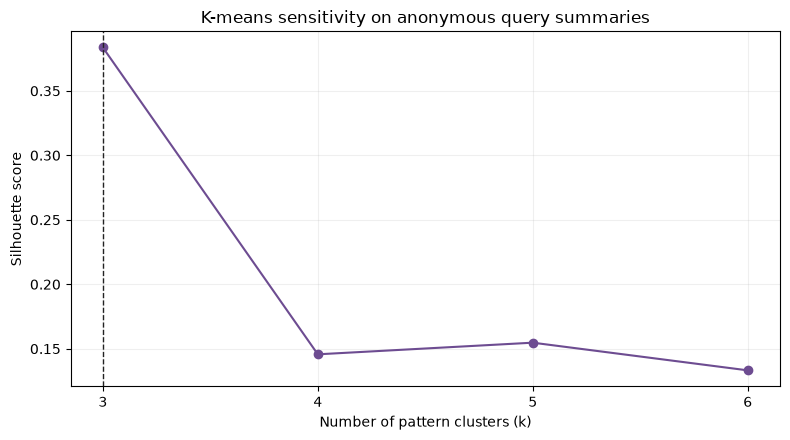

Best descriptive k in the tested range: 3


,k,silhouette,inertia,minimum_cluster_query_count,maximum_cluster_query_count
0,3,0.383637,6345.948589,97,653
1,4,0.145695,5769.112834,43,379
2,5,0.154720,5291.497098,31,379
3,6,0.133258,4967.543752,31,243


In [8]:
sensitivity = cluster_sensitivity.sort_values("k")
best = sensitivity.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]
selected_k = int(best["k"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sensitivity["k"], sensitivity["silhouette"], marker="o", color="#6d4c91")
ax.axvline(selected_k, color="#222222", linestyle="--", linewidth=1)
ax.set_title("K-means sensitivity on anonymous query summaries")
ax.set_xlabel("Number of pattern clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_xticks(sensitivity["k"])
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Best descriptive k in the tested range: {selected_k}")
sensitivity


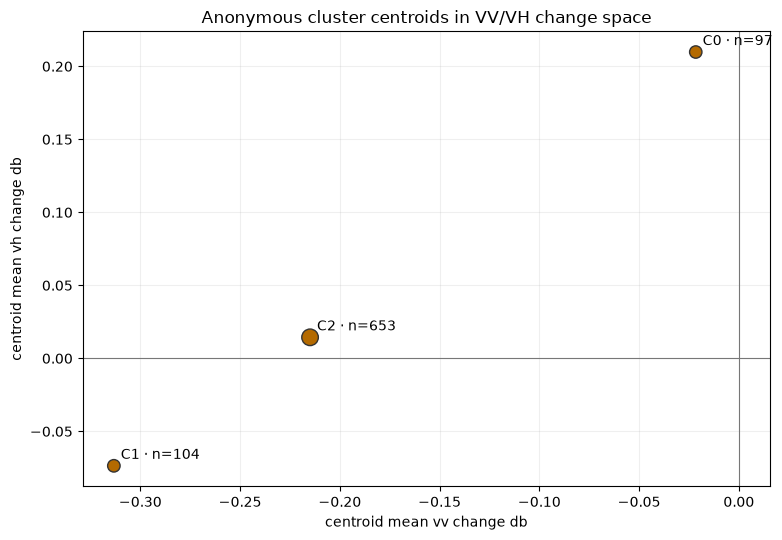

,k,cluster_id,query_count,interpretation,centroid_mean_pre_vv_db,centroid_mean_event_vv_db,centroid_mean_pre_vh_db,centroid_mean_event_vh_db,centroid_mean_vv_change_db,centroid_mean_vh_change_db,centroid_std_pre_vv_db,centroid_std_event_vv_db,centroid_std_pre_vh_db,centroid_std_event_vh_db,centroid_std_vv_change_db,centroid_std_vh_change_db
0,3,0,97,descriptive_backscatter_pattern_not_flood_class,-7.702506,-7.680916,-14.785083,-14.994865,-0.021591,0.209782,3.179393,3.333423,3.236797,3.501698,2.798481,3.323526
1,3,1,104,descriptive_backscatter_pattern_not_flood_class,-4.705562,-4.392311,-13.110048,-13.036457,-0.313250,-0.073590,3.977553,4.003211,3.146285,3.185840,2.353652,2.668557
2,3,2,653,descriptive_backscatter_pattern_not_flood_class,-6.892212,-6.677302,-13.862652,-13.877056,-0.214910,0.014404,2.536418,2.554147,2.493040,2.521650,2.620158,2.867124


In [9]:
selected_clusters = cluster_summary.loc[cluster_summary["k"] == selected_k].copy()
vv_column = next(column for column in selected_clusters if "vv_change" in column)
vh_column = next(column for column in selected_clusters if "vh_change" in column)

fig, ax = plt.subplots(figsize=(8, 5.5))
sizes = 40 + 4 * np.sqrt(selected_clusters["query_count"])
ax.scatter(
    selected_clusters[vv_column],
    selected_clusters[vh_column],
    s=sizes,
    color="#b46a00",
    edgecolor="#333333",
)
for row in selected_clusters.itertuples(index=False):
    ax.annotate(
        f"C{int(row.cluster_id)} · n={int(row.query_count)}",
        (getattr(row, vv_column), getattr(row, vh_column)),
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.axhline(0, color="#777777", linewidth=0.8)
ax.axvline(0, color="#777777", linewidth=0.8)
ax.set_title("Anonymous cluster centroids in VV/VH change space")
ax.set_xlabel(vv_column.replace("_", " "))
ax.set_ylabel(vh_column.replace("_", " "))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

selected_clusters


## Check: why the weak polygon is not a training target

The separate governance inventory records four queries with some weak-positive
cell centres and 850 wholly unreviewed queries. That is positive-unlabelled
evidence: it contains a weak-positive hint, but no trustworthy dry class.

This reviewer-safe notebook intentionally does not load weak-overlap rows or
their identities. Treating all polygon exterior as dry would manufacture the
negative class, making apparent precision, recall, Dice, ROC-AUC, and PR-AUC
circular rather than valid flood metrics.


## Check: design the spatial split before fitting

Randomly splitting neighboring cells would leak scene and local spatial
structure across train and validation. The future committee must split by the
20 governed spatial groups. The following exercise creates anonymous group
folds only; it does not fit a model or reveal real group identities.


In [10]:
random_seed = int(summary["unsupervised_learning"]["random_seed"])
anonymous_groups = np.array([f"G{index:02d}" for index in range(1, counts["spatial_group_count"] + 1)])
fold_rows = []
for repeat in range(1, 4):
    shuffled = np.random.default_rng(random_seed + repeat).permutation(anonymous_groups)
    for fold, validation_groups in enumerate(np.array_split(shuffled, 5), start=1):
        train_groups = set(anonymous_groups) - set(validation_groups)
        overlap = train_groups.intersection(validation_groups)
        fold_rows.append(
            {
                "repeat": repeat,
                "fold": fold,
                "training_group_count": len(train_groups),
                "validation_group_count": len(validation_groups),
                "group_overlap_count": len(overlap),
            }
        )
fold_design = pd.DataFrame(fold_rows)
assert (fold_design["group_overlap_count"] == 0).all()
fold_design


,repeat,fold,training_group_count,validation_group_count,group_overlap_count
0,1,1,16,4,0
1,1,2,16,4,0
2,1,3,16,4,0
3,1,4,16,4,0
4,1,5,16,4,0
5,2,1,16,4,0
6,2,2,16,4,0
7,2,3,16,4,0
8,2,4,16,4,0
9,2,5,16,4,0


## Check: supervised training gate

Logistic regression needs released features paired with released labels.
Histogram gradient boosting needs the same target plus enough spatial groups
and class coverage. Neither model may be trained by relabeling weak exterior as
dry or by importing synthetic practice answers.


In [11]:
training_receipt = pd.DataFrame(
    [
        ("Gate status", summary["training_gate_status"]),
        ("Released real labels", 0),
        ("Release-bound training table", False),
        ("Logistic/HGB fitting performed", False),
        ("Decision-layer eligible", safety["eligible_for_decision_layer"]),
        ("FPPS eligible", safety["eligible_for_fpps"]),
        ("Warning eligible", safety["eligible_for_warning"]),
    ],
    columns=["check", "observed"],
)
training_receipt


,check,observed
0,Gate status,blocked_missing_released_training_labels
1,Released real labels,0
2,Release-bound training table,False
3,Logistic/HGB fitting performed,False
4,Decision-layer eligible,False
5,FPPS eligible,False
6,Warning eligible,False


## Exercises

1. Explain why `vv_change_db = +6` means the event return became darker by
   6 dB, but does not prove flood.
2. Name two flood-compatible and two non-flood explanations for strong
   darkening.
3. Explain why 874,496 cells are not 874,496 independent examples.
4. Explain why a k-means cluster cannot be named “flood” without external
   evidence.
5. Explain why the weak polygon exterior is unknown rather than dry.
6. State which artifact would unlock supervised learning: a verified,
   release-bound training table—not a pseudo-label.

Expected learning: processing and feature integrity can be excellent while
supervised model validity remains blocked by the absence of a trustworthy
target.


## Next steps

### Verified now

- The current real Sentinel-1 pool is complete, finite, formula-consistent, and
  aligned at the governed cell/query/group grain.
- The real scene contains heterogeneous VV/VH change and strongly imbalanced
  static-context strata.
- PCA and k-means can describe feature structure without claiming flood truth.

### Still interpretation, not truth

- Darkening, brightening, cluster membership, and distance from a centroid do
  not establish inundation.
- Static water, land cover, and slope provide context rather than event labels.

### Blocking supervised ML

- There are zero released real labels and no release-bound training table.
- Formal calibration, independent review, adjudication, consensus, QA, freeze,
  and revalidation have not occurred.
- Only one event exists; no Thailand development event or untouched geographic
  test has been opened.

### Exact next executable action

Continue aggregate reviewer-safe orientation and targeted urban-SAR learning.
Unlock the real logistic/HGB notebook sections only after a verified frozen
label release and release-bound training derivation exist.
